Necesito:

1. cargar librerias, cargar datos y generar la muestra del data set.
2. Hacer el EDA, hacer una muestra y delimitar los datos necesarios para esto
3. empezar a armar el modelo CNN con su Transfer learnig
4. Pulir datos antes de generar el stream libt y el LLM



In [1]:
#Conexion a hugging face
# ----------------------------------------
# Pedir la key sin mostrarla
hf_key = getpass("Introduce tu Hugging Face API key: ")

# Guardarla en un archivo .env
with open(".env", "w") as f:
    f.write(f"HF_API_TOKEN={hf_key}\n")  # ahora se llama HF_API_TOKEN
# ----------------------------------------
# Cargar la key desde .env
load_dotenv()
os.environ["HF_API_TOKEN"] = os.getenv("HF_API_TOKEN")  # variable de entorno oficial

# ----------------------------------------
#  Usar la key con Hugging Face
login(token=os.environ["HF_API_TOKEN"])  # autentica la sesión en memoria

api = HfApi()
user = api.whoami()  # prueba que la key funciona

print("✅ Hugging Face API key cargada correctamente")
print("Usuario autenticado:", user["name"])

# Descarga todo el contenido del dataset a un directorio local
snapshot_download(
    repo_id="alkzar90/NIH-Chest-X-ray-dataset",
    repo_type="dataset",
    local_dir=PROYECTI
)

#DESCOMPRIMIMOS LOS ARCHIVOS ZIP
# carpeta donde están los ZIP
zip_folder = "/content/drive/MyDrive/PROYECTI/data/images"

# carpeta donde se extraerán las imágenes
images_folder = os.path.join(zip_folder, "extracted")
os.makedirs(images_folder, exist_ok=True)

# extraer todos los zip
for file in os.listdir(zip_folder):
    if file.endswith(".zip"):
        zip_path = os.path.join(zip_folder, file)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(images_folder)

print("Imágenes extraídas en:", images_folder)

NameError: name 'getpass' is not defined

In [1]:
# BLOQUE DE LIMPIEZA - EJECUTAR SIEMPRE PRIMERO PARA EVITAR BUG DE CNN (KERNEL SUCIO)
# ===================================================================================

import gc
import tensorflow as tf
from tensorflow import keras

# 1. Limpiar sesión de Keras
keras.backend.clear_session()

# 2. Resetear grafos de TensorFlow
tf.compat.v1.reset_default_graph()

# 3. Liberar memoria GPU (si tienes)
try:
    from numba import cuda
    cuda.select_device(0)
    cuda.close()
except:
    pass

# 4. Forzar recolección de basura
gc.collect()

# 5. NO ELIMINAR EL CACHE!!!

print("Kernel limpiado - listo para entrenar")

Kernel limpiado - listo para entrenar


In [1]:
# IMPORTACIONES Y CONFIGURACIÓN DE REPRODUCIBILIDAD
# =================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from PIL import Image

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau


from dotenv import load_dotenv
from huggingface_hub import login, HfApi
from huggingface_hub import snapshot_download
from google.colab import drive
from getpass import getpass
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

import os

np.random.seed(29)
tf.random.set_seed(29)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# --- Conexión a Drive ---
drive.mount('/content/drive')

# --- Rutas ---
PROYECTI = "/content/drive/MyDrive/PROYECTI"
DATASET_PATH = PROYECTI
csv_path = os.path.join(DATASET_PATH, "data", "Data_Entry_2017_v2020.csv")
images_folder = os.path.join(PROYECTI, "data/images/extracted/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# --- Cargar CSV ---
df = pd.read_csv(csv_path)
#Revisamos los datos
print("\nCABECERA\n", df.head(10))
print("\nINFORMACION\n", df.info(10))
print("\nFINAL\n", df.tail(10))


CABECERA
         Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_001.png                  Hernia            0           3   
5  00000003_002.png                  Hernia            1           3   
6  00000003_003.png     Hernia|Infiltration            2           3   
7  00000003_004.png                  Hernia            3           3   
8  00000003_005.png                  Hernia            4           3   
9  00000003_006.png                  Hernia            5           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           57              M            PA                 2682     2749   
1           58              M            P

In [6]:
# --- Filtrado de clases ---
# --- Filtrado limpio ---
infiltration_df = df[df['Finding Labels'] == "Infiltration"].copy()
normal_df = df[df['Finding Labels'] == "No Finding"].copy()

# Labels
infiltration_df["label"] = 1
normal_df["label"] = 0

# Balance real
min_samples = min(len(infiltration_df), len(normal_df))

infiltration_sample = infiltration_df.sample(min_samples, random_state=29)
normal_sample = normal_df.sample(min_samples, random_state=29)

balanced_df = pd.concat([infiltration_sample, normal_sample])
balanced_df = balanced_df.sample(frac=1, random_state=29).reset_index(drop=True)

# Asignar etiquetas
infiltration_df["label"] = 1
normal_df["label"] = 0

# Concatenar
binary_df = pd.concat([infiltration_df, normal_df], ignore_index=True)

# Eliminar duplicados
binary_df = binary_df.drop_duplicates(subset=["Image Index"])

print("\nImagenes de Infiltración Pulmonar:", len(infiltration_df))
print("Imagenes de un Pulmón Normal:", len(normal_df))
print("")
print("Data Antes del balanceo:")
print(binary_df["label"].value_counts())

# -------------------------------
# BALANCEO (ANTES DE CARGAR RAM)
# -------------------------------

TARGET_PER_CLASS = 9000

infiltration_df = binary_df[binary_df["label"] == 1]
normal_df = binary_df[binary_df["label"] == 0]

# Si hay más de 9000, undersampling; si hay menos, oversampling
if len(infiltration_df) >= TARGET_PER_CLASS:
    infiltration_sample = infiltration_df.sample(TARGET_PER_CLASS, random_state=29)
else:
    infiltration_sample = infiltration_df.sample(TARGET_PER_CLASS, replace=True, random_state=29)

if len(normal_df) >= TARGET_PER_CLASS:
    normal_sample = normal_df.sample(TARGET_PER_CLASS, random_state=29)
else:
    normal_sample = normal_df.sample(TARGET_PER_CLASS, replace=True, random_state=29)

balanced_df = pd.concat([infiltration_sample, normal_sample])
balanced_df = balanced_df.sample(frac=1, random_state=29).reset_index(drop=True)

print("\nDespués del balanceo a 6500 por clase:")
print(balanced_df["label"].value_counts())


# -------------------------------
# INDEXAR IMÁGENES
# -------------------------------

all_images = {}
for root, dirs, files in os.walk(images_folder):
    for f in files:
        if not f.startswith('._'):
            all_images[f] = os.path.join(root, f)

def find_image_fast(filename):
    return all_images.get(filename, None)

balanced_df["image_path"] = balanced_df["Image Index"].apply(find_image_fast)
print("\n")
print(f"Imagenes cargadas: {len(balanced_df["image_path"])}")


# Eliminar nulos
balanced_df = balanced_df[balanced_df["image_path"].notnull()]


Imagenes de Infiltración Pulmonar: 9547
Imagenes de un Pulmón Normal: 60361

Data Antes del balanceo:
label
0    60361
1     9547
Name: count, dtype: int64

Después del balanceo a 6500 por clase:
label
1    9000
0    9000
Name: count, dtype: int64


Imagenes cargadas: 18000


In [32]:
infiltration_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],label
0,00000005_006.png,Infiltration,6,5,70,F,PA,2992,2991,0.143,0.143,1
1,00000010_000.png,Infiltration,0,10,84,F,PA,2992,2991,0.143,0.143,1
2,00000011_005.png,Infiltration,5,11,75,M,AP,2500,2048,0.168,0.168,1
3,00000011_007.png,Infiltration,7,11,75,M,PA,2782,2753,0.143,0.143,1
4,00000013_046.png,Infiltration,24,13,56,M,PA,2730,2991,0.143,0.143,1


In [7]:
from sklearn.model_selection import train_test_split

# ======================
# DIVISIÓN EN TRAIN / VAL / TEST
# ======================

# Separamos primero train + temp (val+test)
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.3,          # 70% train, 30% temporal
    stratify=balanced_df['label'],
    random_state=29
)

# Separamos temp en val y test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,          # 15% val, 15% test
    stratify=temp_df['label'],
    random_state=29
)

# Mezclamos los dataframes
train_df = train_df.sample(frac=1, random_state=29).reset_index(drop=True)
val_df   = val_df.sample(frac=1, random_state=29).reset_index(drop=True)
test_df  = test_df.sample(frac=1, random_state=29).reset_index(drop=True)

# Convertimos labels a string para los generators
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

# Revisamos tamaños y balance
print("Train:", len(train_df), train_df['label'].value_counts())
print("Val:", len(val_df), val_df['label'].value_counts())
print("Test:", len(test_df), test_df['label'].value_counts())

Train: 12034 label
1    6027
0    6007
Name: count, dtype: int64
Val: 2579 label
1    1291
0    1288
Name: count, dtype: int64
Test: 2579 label
1    1292
0    1287
Name: count, dtype: int64


In [8]:
print(train_df['label'].value_counts())

label
1    6027
0    6007
Name: count, dtype: int64


In [9]:
# ======================
# PARÁMETROS DEL MODELO
# ======================
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_EPOCHS = 300

# ======================
# DATA AUGMENTATION PRO (OPTIMIZADO PARA RX)
# ======================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Entrenamiento (augmentations + preprocess correcto)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validación y test (SIN augmentations)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ======================
# GENERATORS
# ======================
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ======================
# DEBUG CLAVE (NO LO QUITES)
# ======================
print("\nClases detectadas:", train_generator.class_indices)

import numpy as np
print("Distribución train:", np.bincount(train_generator.classes))
print("Distribución val:", np.bincount(val_generator.classes))

Found 12034 validated image filenames belonging to 2 classes.
Found 2579 validated image filenames belonging to 2 classes.
Found 2579 validated image filenames belonging to 2 classes.

Clases detectadas: {'0': 0, '1': 1}
Distribución train: [6007 6027]
Distribución val: [1288 1291]


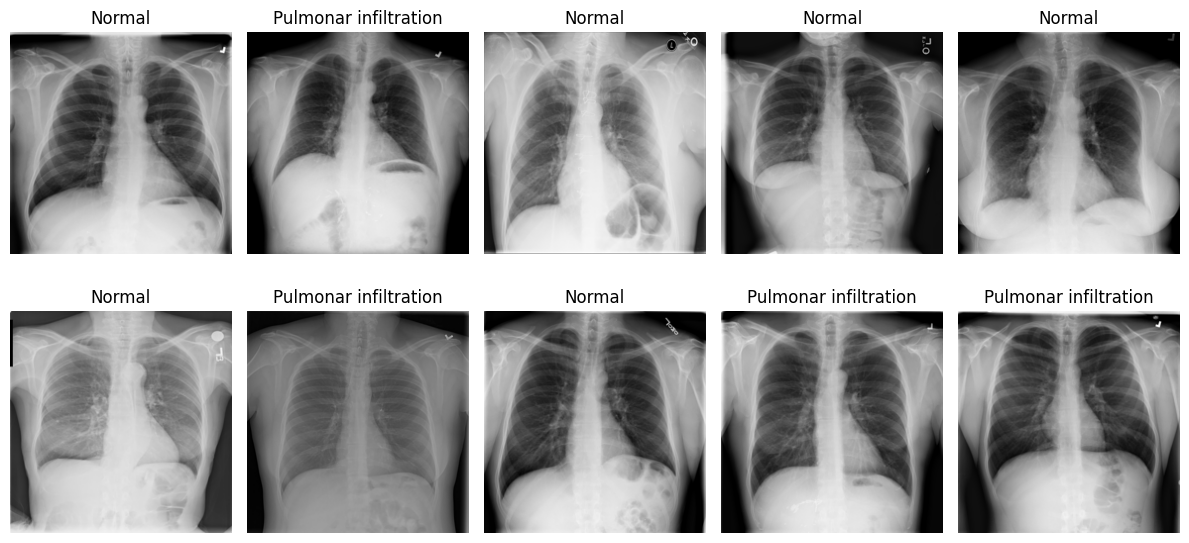

Ditribucion de clases:
Normal: 6007
Infiltration: 6027


In [10]:
# Visualización de imágenes
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

class_names = ["Normal", "Pulmonar infiltration"]
fig, axes = plt.subplots(2, 5, figsize=(12,6))
axes = axes.flatten()

# Elegimos 10 índices aleatorios
random_list = np.random.choice(len(train_df), 10, replace=False)

for i in range(10):
    idx = random_list[i]

    # Ruta de la imagen
    img_path = train_df.iloc[idx]['image_path']
    label = int(train_df.iloc[idx]['label'])

    # Abrimos imagen
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    img = np.array(img)

    axes[i].imshow(img)  # Mostramos en RGB
    axes[i].set_title(f'{class_names[label]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Ditribucion de clases:")
print("Normal:", (train_df['label'] == '0').sum())
print("Infiltration:", (train_df['label'] == '1').sum())


In [21]:
# ======================
# TRANSFER LEARNING CON BASE CONGELADA
# ======================

base_model = ResNet50(
    weights='imagenet',
    include_top = False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False #Congelamos la base

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation= 'relu')(x)
x = Dropout(0.4)(x)

output = Dense(1, activation='sigmoid')(x)#clasificacion Binaria

model = Model(
    inputs = base_model.input,
    outputs = output
    )
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf

# -------------------------
# Compilación del Modelo
# -------------------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')  #  nueva métrica clave
    ]
)

# -------------------------
# Callbacks PRO
# -------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,       # Más paciencia
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

# -------------------------
# Entrenamiento
# -------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=NUM_EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=None,  # ❌ quitamos el peso agresivo
    verbose=1
)

# -------------------------
# Guardado
# -------------------------
model.save("/content/drive/MyDrive/PROYECTI/best_model.h5")



Epoch 1/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5512 - auc: 0.5676 - loss: 0.8157 - precision: 0.5570 - recall: 0.5414
Epoch 1: val_auc improved from None to 0.61624, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 3291s 9s/step - accuracy: 0.5733 - auc: 0.5976 - loss: 0.7119 - precision: 0.5811 - recall: 0.5304 - val_accuracy: 0.5754 - val_auc: 0.6162 - val_loss: 0.6701 - val_precision: 0.5976 - val_recall: 0.4648 - learning_rate: 0.0010
Epoch 2/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.5934 - auc: 0.6382 - loss: 0.6632 - precision: 0.6038 - recall: 0.5310
Epoch 2: val_auc improved from 0.61624 to 0.62509, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 359s 953ms/step - accuracy: 0.5927 - auc: 0.6409 - loss: 0.6612 - precision: 0.6057 - recall: 0.5353 - val_accuracy: 0.5801 - val_auc: 0.6251 - val_loss: 0.6691 - val_precision: 0.6121 - val_recall: 0.4400 - learning_rate: 0.0010
Epoch 3/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.5969 - auc: 0.6473 - loss: 0.6561 - precision: 0.6098 - recall: 0.5361
Epoch 3: val_auc improved from 0.62509 to 0.62787, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 360s 956ms/step - accuracy: 0.5944 - auc: 0.6463 - loss: 0.6571 - precision: 0.6000 - recall: 0.5703 - val_accuracy: 0.5653 - val_auc: 0.6279 - val_loss: 0.6769 - val_precision: 0.6545 - val_recall: 0.2789 - learning_rate: 0.0010
Epoch 4/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.5982 - auc: 0.6481 - loss: 0.6565 - precision: 0.5984 - recall: 0.6234
Epoch 4: val_auc improved from 0.62787 to 0.62962, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 362s 959ms/step - accuracy: 0.6027 - auc: 0.6521 - loss: 0.6556 - precision: 0.5980 - recall: 0.6310 - val_accuracy: 0.5746 - val_auc: 0.6296 - val_loss: 0.6655 - val_precision: 0.6166 - val_recall: 0.3974 - learning_rate: 0.0010
Epoch 5/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.5957 - auc: 0.6471 - loss: 0.6540 - precision: 0.5955 - recall: 0.5982
Epoch 5: val_auc improved from 0.62962 to 0.63232, saving model to best_model.h5


...


Epoch 12: finished saving model to best_model.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 361s 958ms/step - accuracy: 0.6114 - auc: 0.6701 - loss: 0.6439 - precision: 0.6288 - recall: 0.5469 - val_accuracy: 0.5801 - val_auc: 0.6445 - val_loss: 0.6663 - val_precision: 0.5523 - val_recall: 0.8513 - learning_rate: 0.0010
Epoch 13/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.6122 - auc: 0.6664 - loss: 0.6445 - precision: 0.6387 - recall: 0.5227
Epoch 13: val_auc did not improve from 0.64452
377/377 ━━━━━━━━━━━━━━━━━━━━ 362s 960ms/step - accuracy: 0.6119 - auc: 0.6667 - loss: 0.6458 - precision: 0.6420 - recall: 0.5090 - val_accuracy: 0.5882 - val_auc: 0.6419 - val_loss: 0.6661 - val_precision: 0.5586 - val_recall: 0.8451 - learning_rate: 0.0010
Epoch 14/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.6124 - auc: 0.6736 - loss: 0.6411 - precision: 0.6466 - recall: 0.5404
Epoch 14: val_auc did not improve from 0.64452
377/377 ━━━━━━━━━━━━━━━━━━━━ 357s 948ms/step - accuracy:


Epoch 16: finished saving model to best_model.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 353s 935ms/step - accuracy: 0.6158 - auc: 0.6726 - loss: 0.6442 - precision: 0.6474 - recall: 0.5117 - val_accuracy: 0.5905 - val_auc: 0.6466 - val_loss: 0.6570 - val_precision: 0.6325 - val_recall: 0.4345 - learning_rate: 0.0010
Epoch 17/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.6215 - auc: 0.6770 - loss: 0.6428 - precision: 0.6426 - recall: 0.5391
Epoch 17: val_auc did not improve from 0.64661
377/377 ━━━━━━━━━━━━━━━━━━━━ 356s 946ms/step - accuracy: 0.6179 - auc: 0.6726 - loss: 0.6450 - precision: 0.6415 - recall: 0.5376 - val_accuracy: 0.5801 - val_auc: 0.6384 - val_loss: 0.6574 - val_precision: 0.6163 - val_recall: 0.4268 - learning_rate: 0.0010
Epoch 18/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.6211 - auc: 0.6811 - loss: 0.6354 - precision: 0.6446 - recall: 0.5414
Epoch 18: val_auc did not improve from 0.64661
377/377 ━━━━━━━━━━━━━━━━━━━━ 357s 946ms/step - accuracy:


Epoch 21: finished saving model to best_model.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 354s 939ms/step - accuracy: 0.6246 - auc: 0.6860 - loss: 0.6332 - precision: 0.6434 - recall: 0.5620 - val_accuracy: 0.5882 - val_auc: 0.6466 - val_loss: 0.6544 - val_precision: 0.6128 - val_recall: 0.4818 - learning_rate: 5.0000e-04
Epoch 22/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.6320 - auc: 0.6896 - loss: 0.6329 - precision: 0.6452 - recall: 0.5744
Epoch 22: val_auc did not improve from 0.64663
377/377 ━━━━━━━━━━━━━━━━━━━━ 356s 944ms/step - accuracy: 0.6287 - auc: 0.6892 - loss: 0.6321 - precision: 0.6458 - recall: 0.5728 - val_accuracy: 0.5909 - val_auc: 0.6465 - val_loss: 0.6551 - val_precision: 0.6130 - val_recall: 0.4957 - learning_rate: 5.0000e-04
Epoch 23/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.6303 - auc: 0.6861 - loss: 0.6384 - precision: 0.6562 - recall: 0.5486
Epoch 23: val_auc improved from 0.64663 to 0.65114, saving model to best_model.h5



Epoch 23: finished saving model to best_model.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 361s 958ms/step - accuracy: 0.6327 - auc: 0.6906 - loss: 0.6328 - precision: 0.6583 - recall: 0.5545 - val_accuracy: 0.5956 - val_auc: 0.6511 - val_loss: 0.6618 - val_precision: 0.5754 - val_recall: 0.7328 - learning_rate: 5.0000e-04
Epoch 24/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.6277 - auc: 0.6982 - loss: 0.6268 - precision: 0.6413 - recall: 0.5740
Epoch 24: val_auc did not improve from 0.65114
377/377 ━━━━━━━━━━━━━━━━━━━━ 358s 948ms/step - accuracy: 0.6270 - auc: 0.6934 - loss: 0.6305 - precision: 0.6523 - recall: 0.5465 - val_accuracy: 0.5952 - val_auc: 0.6484 - val_loss: 0.6553 - val_precision: 0.6100 - val_recall: 0.5306 - learning_rate: 5.0000e-04
Epoch 25/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.6349 - auc: 0.6930 - loss: 0.6313 - precision: 0.6654 - recall: 0.5500
Epoch 25: val_auc did not improve from 0.65114
377/377 ━━━━━━━━━━━━━━━━━━━━ 358s 948ms/step - a


Epoch 28: finished saving model to best_model.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 358s 950ms/step - accuracy: 0.6341 - auc: 0.6961 - loss: 0.6284 - precision: 0.6599 - recall: 0.5560 - val_accuracy: 0.6076 - val_auc: 0.6531 - val_loss: 0.6559 - val_precision: 0.6042 - val_recall: 0.6266 - learning_rate: 2.5000e-04
Epoch 29/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.6330 - auc: 0.6988 - loss: 0.6272 - precision: 0.6550 - recall: 0.5758
Epoch 29: val_auc did not improve from 0.65305
377/377 ━━━━━━━━━━━━━━━━━━━━ 360s 954ms/step - accuracy: 0.6321 - auc: 0.6958 - loss: 0.6285 - precision: 0.6560 - recall: 0.5582 - val_accuracy: 0.6033 - val_auc: 0.6503 - val_loss: 0.6571 - val_precision: 0.5964 - val_recall: 0.6421 - learning_rate: 2.5000e-04
Epoch 30/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.6344 - auc: 0.6975 - loss: 0.6303 - precision: 0.6611 - recall: 0.5859
Epoch 30: val_auc did not improve from 0.65305
377/377 ━━━━━━━━━━━━━━━━━━━━ 360s 954ms/step - a

In [10]:
model.save("/content/drive/MyDrive/PROYECTI/best_model.h5")

In [25]:
# Asegurar orden correcto (MUY IMPORTANTE)
val_generator.shuffle = False

# Predecir probabilidades
y_pred_probs = model.predict(val_generator, verbose=1)

# Convertir a etiquetas
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Etiquetas reales
y_true = val_generator.classes

# Reporte de clasificación
from sklearn.metrics import classification_report

class_names = ["Normal", "Pulmonar infiltration"]

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

81/81 ━━━━━━━━━━━━━━━━━━━━ 54s 616ms/step
                       precision    recall  f1-score   support

               Normal       0.57      0.69      0.63      1288
Pulmonar infiltration       0.61      0.48      0.54      1291

             accuracy                           0.59      2579
            macro avg       0.59      0.59      0.58      2579
         weighted avg       0.59      0.59      0.58      2579



81/81 ━━━━━━━━━━━━━━━━━━━━ 650s 8s/step


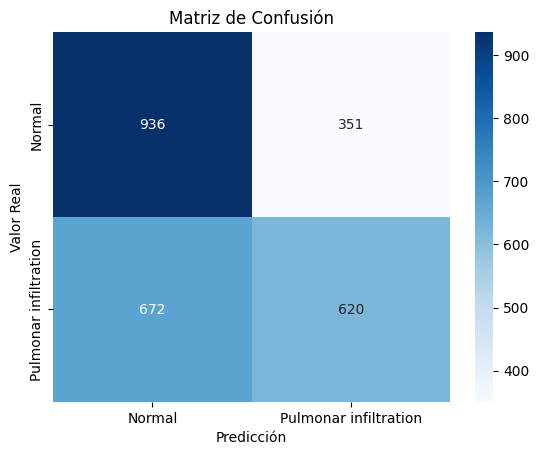

In [26]:
# Asegurar orden correcto
test_generator.shuffle = False

# Predicciones
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Etiquetas reales
y_true = test_generator.classes

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal", "Pulmonar infiltration"],
            yticklabels=["Normal", "Pulmonar infiltration"])

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

In [11]:
# ======================
# LIMPIEZA DATASET (CRÍTICO)
# ======================

def limpiar_dataset(df):
    df = df.copy()
    df['exists'] = df['image_path'].apply(os.path.exists)

    print("❌ Imágenes eliminadas:", (df['exists'] == False).sum())

    return df[df['exists']].drop(columns=['exists'])

train_df = limpiar_dataset(train_df)
val_df = limpiar_dataset(val_df)
test_df = limpiar_dataset(test_df)


# ======================
# DATA GENERATORS (SEGUROS)
# ======================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

BATCH_SIZE = 32
IMG_SIZE = 224

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    validate_filenames=True  # 🔥 evita crashes
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    validate_filenames=True
)


# ======================
# CARGAR MEJOR MODELO (FEATURE EXTRACTION YA HECHO)
# ======================
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/PROYECTI/best_model.h5')

print("✅ Modelo cargado correctamente")


❌ Imágenes eliminadas: 0
❌ Imágenes eliminadas: 0
❌ Imágenes eliminadas: 0
Found 12034 validated image filenames belonging to 2 classes.
Found 2579 validated image filenames belonging to 2 classes.


✅ Modelo cargado correctamente


In [12]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

print(f"Total capas en el modelo: {len(model.layers)}")

# -------------------------
# CALLBACKS PRO 🔥
# -------------------------
callbacks = [
    ModelCheckpoint(
        'best_model_final.h5',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# -------------------------
# 1️⃣ FEATURE EXTRACTION REFORZADA
# -------------------------
for layer in model.layers:
    layer.trainable = False

for layer in model.layers[-10:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

history_fe = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=300,
    callbacks=callbacks,
    class_weight=None,  # ✅ quitado
    verbose=1
)

# -------------------------
# 2️⃣ FINE-TUNING REAL
# -------------------------
for layer in model.layers:
    layer.trainable = False

for layer in model.layers[-80:]:  #  mejor rango
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 🔥 LR correcto
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=300,
    callbacks=callbacks,
    class_weight=None,
    verbose=1
)

# -------------------------
# GUARDADO FINAL
# -------------------------
model.save('/content/drive/MyDrive/PROYECTI/modelo_infiltracion_final.h5')

print("✅ Fine-tuning completado correctamente")

Total capas en el modelo: 179
Epoch 1/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.6225 - auc: 0.6815 - loss: 0.6409 - precision: 0.6488 - recall: 0.5282 
Epoch 1: val_auc improved from None to 0.64661, saving model to best_model_final.h5



Epoch 1: finished saving model to best_model_final.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 5259s 14s/step - accuracy: 0.6161 - auc: 0.6775 - loss: 0.6406 - precision: 0.6478 - recall: 0.5117 - val_accuracy: 0.5971 - val_auc: 0.6466 - val_loss: 0.6569 - val_precision: 0.6123 - val_recall: 0.5321 - learning_rate: 1.0000e-04
Epoch 2/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.6269 - auc: 0.6849 - loss: 0.6372 - precision: 0.6482 - recall: 0.5350
Epoch 2: val_auc did not improve from 0.64661
377/377 ━━━━━━━━━━━━━━━━━━━━ 349s 924ms/step - accuracy: 0.6288 - auc: 0.6859 - loss: 0.6355 - precision: 0.6526 - recall: 0.5533 - val_accuracy: 0.5956 - val_auc: 0.6465 - val_loss: 0.6552 - val_precision: 0.6190 - val_recall: 0.4996 - learning_rate: 1.0000e-04
Epoch 3/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.6224 - auc: 0.6848 - loss: 0.6361 - precision: 0.6535 - recall: 0.5307
Epoch 3: val_auc improved from 0.64661 to 0.64981, saving model to best_model_final.h5



Epoch 3: finished saving model to best_model_final.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 348s 924ms/step - accuracy: 0.6218 - auc: 0.6864 - loss: 0.6352 - precision: 0.6520 - recall: 0.5253 - val_accuracy: 0.5894 - val_auc: 0.6498 - val_loss: 0.6532 - val_precision: 0.6137 - val_recall: 0.4849 - learning_rate: 1.0000e-04
Epoch 4/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.6290 - auc: 0.6868 - loss: 0.6321 - precision: 0.6495 - recall: 0.5352
Epoch 4: val_auc improved from 0.64981 to 0.64994, saving model to best_model_final.h5



Epoch 4: finished saving model to best_model_final.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 355s 941ms/step - accuracy: 0.6289 - auc: 0.6913 - loss: 0.6309 - precision: 0.6500 - recall: 0.5613 - val_accuracy: 0.6041 - val_auc: 0.6499 - val_loss: 0.6562 - val_precision: 0.5916 - val_recall: 0.6754 - learning_rate: 1.0000e-04
Epoch 5/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.6391 - auc: 0.7033 - loss: 0.6247 - precision: 0.6557 - recall: 0.5945
Epoch 5: val_auc did not improve from 0.64994
377/377 ━━━━━━━━━━━━━━━━━━━━ 347s 920ms/step - accuracy: 0.6340 - auc: 0.6979 - loss: 0.6258 - precision: 0.6553 - recall: 0.5681 - val_accuracy: 0.5971 - val_auc: 0.6468 - val_loss: 0.6561 - val_precision: 0.6008 - val_recall: 0.5817 - learning_rate: 1.0000e-04
Epoch 6/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.6364 - auc: 0.7082 - loss: 0.6182 - precision: 0.6541 - recall: 0.5829
Epoch 6: val_auc did not improve from 0.64994
377/377 ━━━━━━━━━━━━━━━━━━━━ 345s 916ms/step - 


Epoch 7: finished saving model to best_model_final.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 350s 928ms/step - accuracy: 0.6400 - auc: 0.7082 - loss: 0.6207 - precision: 0.6563 - recall: 0.5905 - val_accuracy: 0.6060 - val_auc: 0.6548 - val_loss: 0.6563 - val_precision: 0.6244 - val_recall: 0.5345 - learning_rate: 1.0000e-04
Epoch 8/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.6395 - auc: 0.7103 - loss: 0.6145 - precision: 0.6582 - recall: 0.5777
Epoch 8: val_auc did not improve from 0.65482
377/377 ━━━━━━━━━━━━━━━━━━━━ 347s 920ms/step - accuracy: 0.6364 - auc: 0.7048 - loss: 0.6188 - precision: 0.6573 - recall: 0.5723 - val_accuracy: 0.6037 - val_auc: 0.6524 - val_loss: 0.6547 - val_precision: 0.6251 - val_recall: 0.5205 - learning_rate: 1.0000e-04
Epoch 9/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.6494 - auc: 0.7153 - loss: 0.6171 - precision: 0.6758 - recall: 0.5851
Epoch 9: val_auc improved from 0.65482 to 0.66158, saving model to best_model_final.h5



Epoch 9: finished saving model to best_model_final.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 351s 930ms/step - accuracy: 0.6482 - auc: 0.7137 - loss: 0.6192 - precision: 0.6686 - recall: 0.5902 - val_accuracy: 0.6041 - val_auc: 0.6616 - val_loss: 0.6518 - val_precision: 0.6433 - val_recall: 0.4694 - learning_rate: 1.0000e-04
Epoch 10/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.6435 - auc: 0.7142 - loss: 0.6144 - precision: 0.6752 - recall: 0.5690
Epoch 10: val_auc did not improve from 0.66158
377/377 ━━━━━━━━━━━━━━━━━━━━ 341s 903ms/step - accuracy: 0.6451 - auc: 0.7158 - loss: 0.6142 - precision: 0.6673 - recall: 0.5811 - val_accuracy: 0.6146 - val_auc: 0.6602 - val_loss: 0.6573 - val_precision: 0.6228 - val_recall: 0.5833 - learning_rate: 1.0000e-04
Epoch 11/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.6474 - auc: 0.7199 - loss: 0.6068 - precision: 0.6602 - recall: 0.5934
Epoch 11: val_auc improved from 0.66158 to 0.66246, saving model to best_model_final.h5



Epoch 11: finished saving model to best_model_final.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 343s 910ms/step - accuracy: 0.6468 - auc: 0.7171 - loss: 0.6096 - precision: 0.6629 - recall: 0.5995 - val_accuracy: 0.6157 - val_auc: 0.6625 - val_loss: 0.6535 - val_precision: 0.6468 - val_recall: 0.5120 - learning_rate: 1.0000e-04
Epoch 12/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.6466 - auc: 0.7195 - loss: 0.6101 - precision: 0.6623 - recall: 0.5959
Epoch 12: val_auc did not improve from 0.66246
377/377 ━━━━━━━━━━━━━━━━━━━━ 342s 907ms/step - accuracy: 0.6453 - auc: 0.7212 - loss: 0.6089 - precision: 0.6601 - recall: 0.6016 - val_accuracy: 0.6014 - val_auc: 0.6443 - val_loss: 0.6660 - val_precision: 0.5813 - val_recall: 0.7281 - learning_rate: 1.0000e-04
Epoch 13/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.6532 - auc: 0.7262 - loss: 0.6047 - precision: 0.6624 - recall: 0.6167
Epoch 13: val_auc did not improve from 0.66246
377/377 ━━━━━━━━━━━━━━━━━━━━ 344s 912ms/st


Epoch 20: finished saving model to best_model_final.h5
377/377 ━━━━━━━━━━━━━━━━━━━━ 352s 934ms/step - accuracy: 0.6828 - auc: 0.7592 - loss: 0.5776 - precision: 0.6926 - recall: 0.6594 - val_accuracy: 0.6157 - val_auc: 0.6629 - val_loss: 0.6572 - val_precision: 0.6210 - val_recall: 0.5964 - learning_rate: 9.0000e-06
Epoch 21/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 819ms/step - accuracy: 0.6910 - auc: 0.7671 - loss: 0.5748 - precision: 0.7001 - recall: 0.6646
Epoch 21: val_auc did not improve from 0.66289
377/377 ━━━━━━━━━━━━━━━━━━━━ 355s 941ms/step - accuracy: 0.6856 - auc: 0.7627 - loss: 0.5769 - precision: 0.6927 - recall: 0.6693 - val_accuracy: 0.6107 - val_auc: 0.6620 - val_loss: 0.6573 - val_precision: 0.6118 - val_recall: 0.6081 - learning_rate: 9.0000e-06
Epoch 22/300
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.6869 - auc: 0.7658 - loss: 0.5739 - precision: 0.6951 - recall: 0.6788
Epoch 22: val_auc did not improve from 0.66289
377/377 ━━━━━━━━━━━━━━━━━━━━ 348s 923ms/st

✅ Fine-tuning completado correctamente


In [14]:
from tensorflow.keras.models import load_model

# 1️⃣ Cargar modelo
model = load_model('/content/drive/MyDrive/PROYECTI/modelo_infiltracion_final.h5')

# 2️⃣ Compilar nuevamente con tus métricas
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

model.compile(
    optimizer=Adam(learning_rate=5e-8),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall')]
)

# 3️⃣ Evaluar rápido sobre test para inicializar métricas
model.evaluate(test_generator, verbose=1)


81/81 ━━━━━━━━━━━━━━━━━━━━ 678s 8s/step - accuracy: 0.6064 - auc: 0.6722 - loss: 0.6492 - recall: 0.5101


[0.6491937041282654,
 0.6064366102218628,
 0.6722087860107422,
 0.5100619196891785]

In [15]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Probabilidades
y_pred_probs = model.predict(test_generator, verbose=0).flatten()
y_true = test_generator.classes

# Probar distintos thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0.5
best_recall = 0

print("Threshold | Precision | Recall | F1")
print("-----------------------------------")

for t in thresholds:
    y_pred = (y_pred_probs > t).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"{t:.2f}      | {precision:.3f}     | {recall:.3f} | {f1:.3f}")

    # Elegimos el que maximiza recall
    if recall > best_recall:
        best_recall = recall
        best_threshold = t

print("\n Mejor threshold encontrado:", best_threshold)

Threshold | Precision | Recall | F1
-----------------------------------
0.10      | 0.505     | 0.996 | 0.670
0.15      | 0.509     | 0.985 | 0.671
0.20      | 0.516     | 0.978 | 0.676
0.25      | 0.530     | 0.971 | 0.686
0.30      | 0.538     | 0.957 | 0.688
0.35      | 0.550     | 0.932 | 0.692
0.40      | 0.564     | 0.889 | 0.690
0.45      | 0.589     | 0.800 | 0.678
0.50      | 0.633     | 0.510 | 0.565
0.55      | 0.686     | 0.338 | 0.453
0.60      | 0.733     | 0.245 | 0.367
0.65      | 0.752     | 0.180 | 0.291
0.70      | 0.748     | 0.133 | 0.226
0.75      | 0.776     | 0.104 | 0.184
0.80      | 0.789     | 0.078 | 0.142
0.85      | 0.852     | 0.053 | 0.101

 Mejor threshold encontrado: 0.1


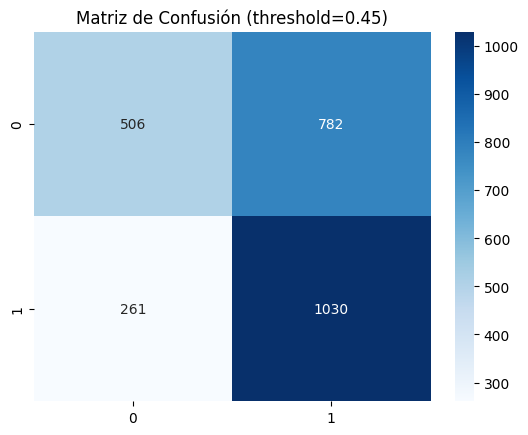

In [20]:
#MATRIZ DE CONFUSION
y_pred = (y_pred_probs > 0.45).astype(int)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusión (threshold=0.45)')
plt.show()

In [19]:
# Asegurar orden correcto (MUY IMPORTANTE)
val_generator.shuffle = False

# Predecir probabilidades
y_pred_probs = model.predict(val_generator, verbose=1)

# Convertir a etiquetas
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Etiquetas reales
y_true = val_generator.classes

# Reporte de clasificación
from sklearn.metrics import classification_report

class_names = ["Normal", "Pulmonar infiltration"]

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

81/81 ━━━━━━━━━━━━━━━━━━━━ 698s 9s/step
                       precision    recall  f1-score   support

               Normal       0.59      0.67      0.63      1288
Pulmonar infiltration       0.62      0.54      0.57      1291

             accuracy                           0.60      2579
            macro avg       0.61      0.60      0.60      2579
         weighted avg       0.61      0.60      0.60      2579



81/81 ━━━━━━━━━━━━━━━━━━━━ 42s 515ms/step


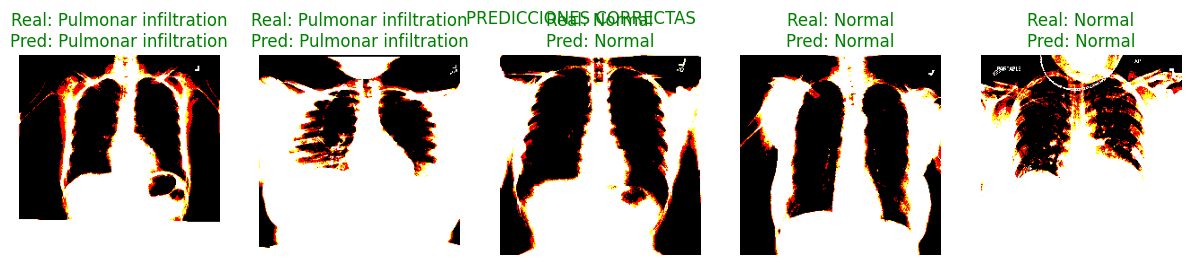

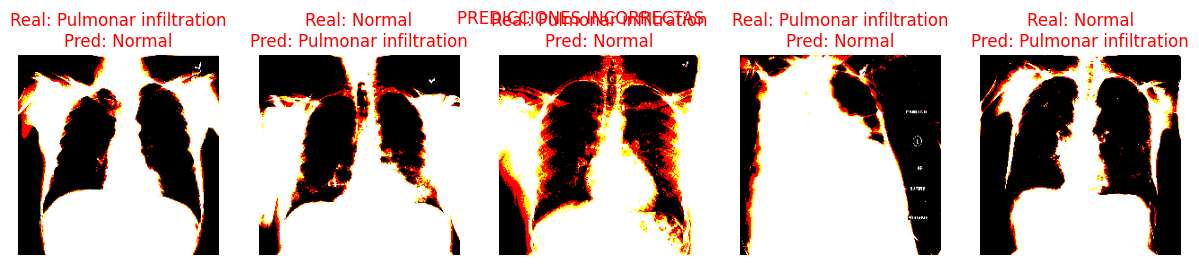

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

#FUNCION PARA DESNORMALIZAR

def denormalize(img):
  img = img.copy()
  img[:, :, 0] += 103.939
  img[:, :, 1] += 116.779
  img[:, :, 2] += 123.68
  return np.clip(img/255.0, 0, 1)


# Asegurarse que las imágenes no se mezclen
test_generator.shuffle = False

# Predicciones
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Etiquetas reales
y_true = test_generator.classes

# Índices correctos e incorrectos
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

# Número de imágenes a mostrar
n_correct = min(5, len(correct_indices))
n_incorrect = min(5, len(incorrect_indices))

# -------------------------
# Predicciones correctas
# -------------------------
fig, axes = plt.subplots(1, n_correct, figsize=(15, 3))
for i in range(n_correct):
    idx = correct_indices[i]
    img, label = test_generator[idx]  # Obtenemos imagen y label desde el generator
    axes[i].imshow(img[0])  # img viene dentro de un batch, por eso [0]
    axes[i].set_title(f'Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}', color='green')
    axes[i].axis('off')

plt.suptitle('PREDICCIONES CORRECTAS\n\n\n\n\n\n', color='green')
plt.show()

# -------------------------
# Predicciones incorrectas
# -------------------------
fig, axes = plt.subplots(1, n_incorrect, figsize=(15, 3))
for i in range(n_incorrect):
    idx = incorrect_indices[i]
    img, label = test_generator[idx]
    axes[i].imshow(img[0])
    axes[i].set_title(f'Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}', color='red')
    axes[i].axis('off')

plt.suptitle('PREDICCIONES INCORRECTAS\n\n\n\n\n\n', color='red')
plt.show()

In [24]:
#Generamos las predicciones del modelo

#probabilidades:
y_pred_probs = model.predict(test_generator, verbose=1).flatten()

#valores reales:
y_true = test_generator.classes

#nombres de las imagenes

image_names = [path.split('/')[-1] for path in test_generator.filepaths]

#Creamos el dataframe:

df_test = pd.DataFrame({
    'image': image_names,
    'y_true': y_true,
    'y_pred_probs': y_pred_probs
})

#Guardar CSV
csv_path = '/content/drive/MyDrive/PROYECTI/test_predictions.csv'
df_test.to_csv(csv_path, index=False)

print("✅ CSV guardado correctamente")

81/81 ━━━━━━━━━━━━━━━━━━━━ 43s 527ms/step
✅ CSV guardado correctamente


In [25]:
import os
import json
from datetime import datetime
from tensorflow.keras.models import load_model

drive_base = '/content/drive/MyDrive/PROYECTI'
os.makedirs(drive_base, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

MODEL_PATH = os.path.join(drive_base,f'Final_model_{timestamp}.keras')
BEST_MODEL_PATH = os.path.join(drive_base, f'best_model_{timestamp}.keras')
CLASS_PATH = os.path.join(drive_base, f'class_names_{timestamp}.json')
CONFIG_PATH = os.path.join(drive_base, f'config_{timestamp}.json')
SUMMARY_JSON = os.path.join(drive_base, f'summary_paths_{timestamp}.json')

#GUARDAMOS MEJOR MODELO FINAL
model.save(MODEL_PATH)
print("✅ Modelo final guardado")

# --------------------------
# Guardar mejor modelo
# --------------------------
if os.path.exists('best_model.keras'):
    best_model = load_model('best_model.keras')
    best_model.save(BEST_MODEL_PATH)
    print("✅ Mejor modelo guardado")
else:
    BEST_MODEL_PATH = None
    print("⚠️ No se encontró best_model.keras")

# --------------------------
# Clases
# --------------------------
class_names = ["Normal", "Pulmonar infiltration"]

with open(CLASS_PATH, 'w') as f:
    json.dump(class_names, f)

# --------------------------
# Configuración
# --------------------------
config = {
    "img_size": 224,
    "batch_size": 32,
    "learning_rate": 3e-4,
    "num_epochs": 20,
    "threshold": 0.5,
    "date": timestamp
}

with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f)

# --------------------------
# Resumen
# --------------------------
summary = {
    "model_final": MODEL_PATH,
    "best_model": BEST_MODEL_PATH,
    "classes_json": CLASS_PATH,
    "config_json": CONFIG_PATH
}

with open(SUMMARY_JSON, 'w') as f:
    json.dump(summary, f, indent=4)

print("✅ Todo guardado correctamente")

✅ Modelo final guardado
⚠️ No se encontró best_model.keras
✅ Todo guardado correctamente
